In [ ]:
"""
Aperiodic (1/f) Parameterization of NREM Sleep EEG in IESS
============================================================
 
Purpose

This code lets you test whether the treatment-related changes in theta/alpha/sigma/
gamma/delta power (Pre -> Post1 -> Post2) reflect genuine oscillatory
reorganization, a broadband tilt of the aperiodic slope, or both. It also
gives you an independent, biologically interpretable marker (aperiodic
exponent, linked to cortical E/I balance) to report alongside SWI and PAC.
 
Requirements
------------
pip install --break-system-packages mne specparam pandas scipy statsmodels
 
Expected input
--------------
This script assumes, per subject and per timepoint (Pre / Post1 / Post2), you
have either:
  (a) a continuous MNE-readable raw file (.fif, .edf, .set, .vhdr, ...) plus
      annotations/events marking the 30-s NREM epochs already scored, OR
  (b) a pre-epoched .fif file (mne.Epochs saved with epochs.save) where each
      epoch is a scored 30-s NREM segment.
 
Edit `load_epochs_for_recording()` below to match whichever you actually have
-- that is the only part that is dataset-specific. Everything downstream
(PSD -> specparam fit -> aggregation -> stats) is generic.
 
Directory / manifest convention assumed here (adjust as needed):
    manifest.csv with columns: subject, timepoint, filepath
    e.g.
        subject,timepoint,filepath
        S01,Pre,/data/S01_pre_epo.fif
        S01,Post1,/data/S01_post1_epo.fif
        S01,Post2,/data/S01_post2_epo.fif
        S02,Pre,/data/S02_pre_epo.fif
        ...
"""

In [27]:
import warnings
import numpy as np
import pandas as pd
import mne
from scipy.stats import kurtosis
from specparam import SpectralModel
from specparam.bands import Bands
from specparam.data.periodic import get_band_peak_arr
 
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore")

In [28]:
# ----------------------------------------------------------------------
# 1. CONFIGURATION -- match these to your study
# ----------------------------------------------------------------------
 
MANIFEST_CSV = "manifest.csv"          # subject, timepoint, filepath
OUTPUT_CSV = "aperiodic_results.csv"
 
# Frequency range to fit. Excludes very low frequencies (drift/filter
# artifacts) and anything above 45 Hz (your recording's upper bound / line
# noise region). specparam fits are unreliable right at the recording edges,
# so 1-45 is a reasonable default given your 0.5-45 Hz recording band.
FIT_FREQ_RANGE = (1.0, 45.0)
 
# Welch PSD parameters. For 30-s epochs, a 4-s window with 50% overlap gives
# ~0.25 Hz resolution -- fine enough to resolve delta/theta/alpha peaks
# without being noisy.
WELCH_N_FFT = None       # set to sfreq*4 once sfreq is known (done per-file below)
WELCH_N_OVERLAP_FRAC = 0.5
 
# Band definitions matching your 8-band scheme (adjust edges to match your
# actual analysis if they differ slightly)
BANDS = Bands({
    "slow_delta": (0.5, 2),
    "delta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "sigma": (13, 16),
    "beta": (16, 30),
    "gamma": (30, 45),
})
 
# Whether to fit with a "knee" term (recommended when the spectrum isn't a
# clean straight line in log-log space across your full fit range, which is
# common in pediatric EEG with a sigma/spindle hump). Try 'fixed' first and
# inspect residuals/reports; switch to 'knee' if fits look poor at low freq.
APERIODIC_MODE = "fixed"   # or "knee"
 
 


In [29]:
# sanity check: load a single EDF file and inspect its info, annotations, and durations

raw = mne.io.read_raw_edf(r"J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2_Post2.edf", preload=False)
print(raw.info)
print(set(raw.annotations.description))
print(raw.annotations.duration[:20])

<Info | 8 non-empty values
 bads: []
 ch_names: C3, C4, Cz, F3, F4, F7, F8, Fz, Fp1, Fp2, Fpz, A1, A2, O1, O2, ...
 chs: 103 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2024-01-17 10:01:07 UTC
 nchan: 103
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: ELE,03>
>
set()
[]


In [40]:
# ----------------------------------------------------------------------
# 2. DATA LOADING -- single pre-confirmed 30-s N2 epoch per file
# ----------------------------------------------------------------------
 
# Some of your recordings use the OLDER 10-20 temporal electrode names
# (T3/T4/T5/T6) instead of the newer 10-10 equivalents (T7/T8/P7/P8) --
# same physical electrode positions, different naming convention, seen on
# your lower-density montages specifically. Renamed on load so both
# conventions resolve to one canonical name before channel-set validation.
CHANNEL_ALIASES = {
    "T3": "T7",
    "T4": "T8",
    "T5": "P7",
    "T6": "P8",
}
 
 
# Your EDFs have highpass=0.0 Hz applied (confirmed via raw.info) -- i.e.
# genuinely unfiltered. This lets slow baseline drift/DC wander dominate
# peak-to-peak amplitude over a 30-s window, which showed up as near-
# universal false-positive artifact flags (kurtosis near 0 -- not spiky/
# artifactual, just drift). Filtering here, once, so QC metrics, PSD, and
# the aperiodic fit all see the same corrected signal.
# Your EDFs have highpass=0.0 Hz applied (confirmed via raw.info) -- i.e.
# genuinely unfiltered. This lets slow baseline drift/DC wander dominate
# peak-to-peak amplitude over a 30-s window. Filtering here, once, so QC
# metrics, PSD, and the aperiodic fit all see the same corrected signal.
HIGHPASS_HZ = 0.5   # matches your lowest analyzed band edge (slow delta)
 
# Confirmed via PSD inspection: several files show a sharp 60 Hz spike
# (US power-line interference), concentrated in channels referenced
# through A1 specifically -- consistent with a noisy/high-impedance
# reference electrode. Notch-filtered here (60 Hz + its 120 Hz harmonic)
# alongside the high-pass drift correction, so QC metrics, PSD, and the
# aperiodic fit all see the corrected signal.
NOTCH_FREQS = [60.0, 120.0]
 
 
# Filtering a short, hard-edged 30-s segment produces transient "ringing"
# artifacts at the very start/end (confirmed via testing: elevated
# amplitude/kurtosis concentrated in the last ~1s post-filtering). Crop
# this much off each edge AFTER filtering so QC/PSD/fitting see only the
# stable central portion. Applied identically to every file, so it doesn't
# bias cross-timepoint comparisons -- just shortens the analyzed window
# from 30s to (30 - 2*EDGE_CROP_SEC)s for everyone equally.
EDGE_CROP_SEC = 1.0
 
 
def load_single_epoch(filepath, highpass=HIGHPASS_HZ, notch_freqs=NOTCH_FREQS,
                       edge_crop=EDGE_CROP_SEC):
    """
    Load one EDF file. The entire file IS the 30-s N2 epoch -- no event
    search, no sub-epoching.
 
    Applies, in order:
      1. CHANNEL_ALIASES  -- old/new 10-20 temporal naming -> one canonical name
      2. High-pass filter  -- removes unfiltered baseline drift (see HIGHPASS_HZ)
      3. Notch filter       -- removes confirmed 60 Hz line noise + harmonic
                               (see NOTCH_FREQS). Set notch_freqs=None to skip.
      4. Edge crop          -- removes filter ringing transients at both
                               ends (see EDGE_CROP_SEC). Set edge_crop=None
                               to skip.
    """
    raw = mne.io.read_raw_edf(filepath, preload=True)
    raw.pick("eeg")
 
    # case-insensitive alias application: build the actual rename dict
    # from whatever case this file's channel names happen to use
    rename_map = {}
    for ch in raw.ch_names:
        canonical = CHANNEL_ALIASES.get(ch.upper())
        if canonical is not None:
            rename_map[ch] = canonical
    if rename_map:
        raw.rename_channels(rename_map)
 
    if highpass is not None:
        raw.filter(l_freq=highpass, h_freq=None, verbose=False)
 
    if notch_freqs is not None:
        raw.notch_filter(freqs=notch_freqs, verbose=False)
 
    if edge_crop is not None:
        raw.crop(tmin=edge_crop, tmax=raw.times[-1] - edge_crop)
 
    return raw
 
 
def find_common_channels(manifest_csv=None, manifest_df=None):
    """
    Scan every file in the manifest and return the intersection of channel
    names present in ALL of them. Useful as a first exploratory look, but
    note this can include non-scalp/auxiliary channels if your recording
    system has them. For the actual analysis, prefer a fixed, clinically
    -defined scalp set -- see SCALP_CHANNELS and validate_channel_set()
    below instead.
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)
 
    common = None
    per_file_channels = {}
    for _, row in manifest_df.iterrows():
        raw = load_single_epoch(row["filepath"])  # applies CHANNEL_ALIASES
        chs = set(ch.upper() for ch in raw.ch_names)  # case-insensitive match
        per_file_channels[f"{row['subject']}_{row['timepoint']}"] = chs
        common = chs if common is None else (common & chs)
 
    print("Channels present in EVERY file (intersection):")
    print(sorted(common))
    print(f"\n{len(common)} common channels out of "
          f"{max(len(c) for c in per_file_channels.values())} max seen in any single file.")
 
    for name, chs in per_file_channels.items():
        missing = common - chs if common else set()
        if missing:
            print(f"  (sanity check) {name} is missing: {missing}")  # should be empty by construction
 
    return sorted(common)
 
 
# Fixed, clinically-defined scalp channel set (standard 10-20 positions).
# NOTE: OZ, FPZ, T1, T2 were dropped from the original 25-channel request --
# validate_channel_set() showed these are genuinely absent (not a naming
# issue) in several of your files even after alias correction above. Keeping
# them would mean different files contribute different channels, which
# breaks a fair cross-timepoint comparison.
SCALP_CHANNELS = [
    "C3", "C4", "CZ",
    "F3", "F4", "F7", "F8", "FZ",
    "FP1", "FP2",
    "A1", "A2",
    "O1", "O2",
    "P3", "P4", "P7", "P8", "PZ",
    "T7", "T8",
]
 
 
def validate_channel_set(manifest_csv=None, manifest_df=None, channel_set=SCALP_CHANNELS):
    """
    Check that every file in the manifest actually has every channel in
    `channel_set`, AFTER alias correction (see CHANNEL_ALIASES / 
    load_single_epoch). Prints per-file gaps so you catch genuine absences
    versus naming mismatches before they silently drop a channel from one
    file's fit.
 
    Returns the channel_set unchanged (for convenience / chaining), but
    you should read the printed output before trusting it.
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)
 
    target = set(ch.upper() for ch in channel_set)
    all_ok = True
    for _, row in manifest_df.iterrows():
        raw = load_single_epoch(row["filepath"])  # applies CHANNEL_ALIASES
        present = set(ch.upper() for ch in raw.ch_names)
        missing = target - present
        label = f"{row['subject']} / {row['timepoint']}"
        if missing:
            all_ok = False
            print(f"  MISSING in {label}: {sorted(missing)}")
        else:
            print(f"  OK: {label} has all {len(target)} channels")
 
    if all_ok:
        print(f"\nAll files contain all {len(target)} channels in the requested set.")
    else:
        print("\nSome files are missing channels above -- check for naming "
              "differences before assuming they're truly absent.")
 
    return channel_set
 
 
def inspect_raw_for_qc(filepath, duration=30.0):
    """
    Visual QC helper. Opens an interactive plot (run in a notebook cell).
    Note channels/segments that look artifactual; feed that into the
    `exclude` dict in run_pipeline().
    """
    raw = load_single_epoch(filepath)
    raw.plot(duration=duration, n_channels=20, scalings="auto", block=False)
    return raw

In [41]:
 
# ----------------------------------------------------------------------
# 2b. ARTIFACT DETECTION -- automated flagging + targeted visual review
# ----------------------------------------------------------------------
#
# Strategy: since these are RAW, uncleaned single 30-s segments, run cheap,
# objective per-channel metrics on every channel in every file first. Flag
# anything that crosses a threshold, THEN visually inspect only the flagged
# channels (not all 252 channel-recordings) before deciding to exclude them.
# This is much faster than blind full review, but still keeps a human in
# the loop for the actual exclusion decision -- automated thresholds alone
# shouldn't silently drive what gets dropped from an n=4 study.
 
# Defaults are a starting point, not a validated clinical threshold --
# adjust after looking at your first summary table (see below).
PTP_MAX_UV = 300.0   # peak-to-peak amplitude above this -> likely artifact
                      # (movement, electrode pop, muscle) for infant scalp EEG
PTP_MIN_UV = 1.0      # peak-to-peak amplitude below this -> likely flat/
                      # disconnected electrode
KURTOSIS_MAX = 5.0    # high kurtosis -> peaky/spiky signal, often artifact
                       # rather than genuine oscillatory activity
 
 
def compute_channel_qc_metrics(raw):
    """
    Per-channel QC metrics for one recording (one file = one 30-s segment).
 
    Returns a DataFrame with one row per channel: peak-to-peak amplitude
    (uV), standard deviation (uV), and kurtosis of the raw signal.
    """
    data = raw.get_data(units="uV")  # (n_channels, n_samples)
    ptp = data.max(axis=1) - data.min(axis=1)
    std = data.std(axis=1)
    kurt = kurtosis(data, axis=1, fisher=True)  # 0 = normal distribution
 
    return pd.DataFrame({
        "channel": raw.ch_names,
        "ptp_uv": ptp,
        "std_uv": std,
        "kurtosis": kurt,
    })
 
 
def flag_bad_channels(raw, ptp_max=PTP_MAX_UV, ptp_min=PTP_MIN_UV, kurt_max=KURTOSIS_MAX):
    """
    Apply threshold-based flags to one recording's channels.
 
    Returns
    -------
    flagged : list of (channel_name, reason) tuples
    metrics : the full QC metrics DataFrame (for inspection/plotting)
    """
    metrics = compute_channel_qc_metrics(raw)
    flagged = []
    for _, row in metrics.iterrows():
        reasons = []
        if row["ptp_uv"] > ptp_max:
            reasons.append(f"ptp={row['ptp_uv']:.0f}uV > {ptp_max}")
        if row["ptp_uv"] < ptp_min:
            reasons.append(f"ptp={row['ptp_uv']:.2f}uV < {ptp_min} (flat?)")
        if abs(row["kurtosis"]) > kurt_max:
            reasons.append(f"kurtosis={row['kurtosis']:.1f}")
        if reasons:
            flagged.append((row["channel"], "; ".join(reasons)))
    return flagged, metrics
 
 
def run_qc_summary(manifest_csv=MANIFEST_CSV, manifest_df=None,
                    channels_to_use=None, ptp_max=PTP_MAX_UV,
                    ptp_min=PTP_MIN_UV, kurt_max=KURTOSIS_MAX):
    """
    Run automated flagging across every file in the manifest. Prints a
    per-file summary and returns:
      - flags_df: long-format DataFrame of every flagged channel, with
        reason, for every subject/timepoint (this is what you inspect)
      - exclude_dict: ready to pass straight into run_pipeline(exclude=...)
        once you've reviewed flags_df and decided which flags are real
    """
    if manifest_df is None:
        manifest_df = pd.read_csv(manifest_csv)
 
    all_flags = []
    for _, row in manifest_df.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        raw = load_single_epoch(filepath)
        if channels_to_use is not None:
            present = [ch for ch in channels_to_use if ch in raw.ch_names]
            raw = raw.copy().pick(present)
 
        flagged, metrics = flag_bad_channels(raw, ptp_max, ptp_min, kurt_max)
        for ch_name, reason in flagged:
            all_flags.append({
                "subject": subject, "timepoint": timepoint,
                "channel": ch_name, "reason": reason,
            })
 
        label = f"{subject} / {timepoint}"
        if flagged:
            print(f"  {label}: {len(flagged)} channel(s) flagged -> "
                  f"{[f[0] for f in flagged]}")
        else:
            print(f"  {label}: clean (no flags)")
 
    flags_df = pd.DataFrame(all_flags)
    print(f"\nTotal flags: {len(flags_df)} across "
          f"{flags_df[['subject','timepoint']].drop_duplicates().shape[0] if len(flags_df) else 0} recordings")
    if len(flags_df):
        print("\nReview flags_df, then visually confirm with e.g.:")
        print('  inspect_raw_for_qc("path/to/that/file.edf")')
        print("before excluding -- thresholds are a starting point, not ground truth.")
 
    # Build exclude dict directly usable by run_pipeline
    exclude_dict = {}
    for _, row in flags_df.iterrows():
        key = (row["subject"], row["timepoint"])
        exclude_dict.setdefault(key, []).append(row["channel"])
 
    return flags_df, exclude_dict
 

In [42]:
flags_df, exclude_dict = run_qc_summary(manifest_csv="manifest.csv", channels_to_use=channels_to_use)

  ELE03 / Pre: 16 channel(s) flagged -> ['C3', 'C4', 'F3', 'F4', 'F7', 'F8', 'A1', 'A2', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'T7', 'T8']
  ELE03 / Post1: 7 channel(s) flagged -> ['F4', 'F7', 'F8', 'A1', 'A2', 'P7', 'T8']
  ELE03 / Post2: 8 channel(s) flagged -> ['C3', 'A1', 'A2', 'O1', 'O2', 'P7', 'P8', 'T7']
  ELE04 / Pre: 14 channel(s) flagged -> ['C3', 'C4', 'F3', 'F4', 'F7', 'F8', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'T7', 'T8']
  ELE04 / Post1: 12 channel(s) flagged -> ['C4', 'F8', 'A1', 'A2', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'T7', 'T8']
  ELE04 / Post2: 6 channel(s) flagged -> ['O1', 'O2', 'P3', 'P4', 'P7', 'P8']
  ELE05 / Pre: 12 channel(s) flagged -> ['C3', 'C4', 'F3', 'F8', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'T7', 'T8']
  ELE05 / Post1: 4 channel(s) flagged -> ['A2', 'O1', 'O2', 'P8']
  ELE05 / Post2: 2 channel(s) flagged -> ['A2', 'T8']
  ELE07 / Pre: 15 channel(s) flagged -> ['C3', 'C4', 'F4', 'F7', 'F8', 'A1', 'A2', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'T7', 'T8']
  ELE07

In [43]:
raw = load_single_epoch(r"J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2_Pre.edf")
present = [ch for ch in channels_to_use if ch in raw.ch_names]
raw = raw.copy().pick(present)
metrics = compute_channel_qc_metrics(raw)
print(metrics.sort_values("ptp_uv", ascending=False))

   channel       ptp_uv      std_uv  kurtosis
13      P8  1482.810951  201.640887  0.523765
15      T8  1418.445064  202.512615  0.573980
9       O2  1299.827473  185.040057  0.608435
11      P4  1283.104590  164.409376  1.357903
0       C3  1282.257600  165.698855  0.900646
1       C4  1272.721403  154.127640  1.811212
6       A1  1213.375154  158.235189  0.621485
7       A2  1192.479477  158.403627  0.602647
10      P3  1189.551165  163.279206  0.286866
8       O1  1169.661823  157.614908  1.128941
14      T7  1057.409915  159.547800  0.197166
12      P7   972.321639  154.397020  0.073453
2       F3   910.457085  129.673446  0.921976
5       F8   877.592594  110.296891  1.618963
3       F4   777.570882  102.680906  0.860051
4       F7   760.306204  105.435150  0.908877


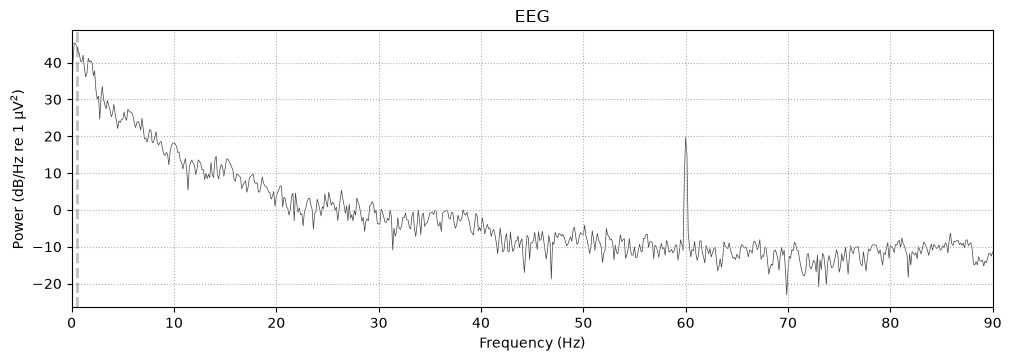

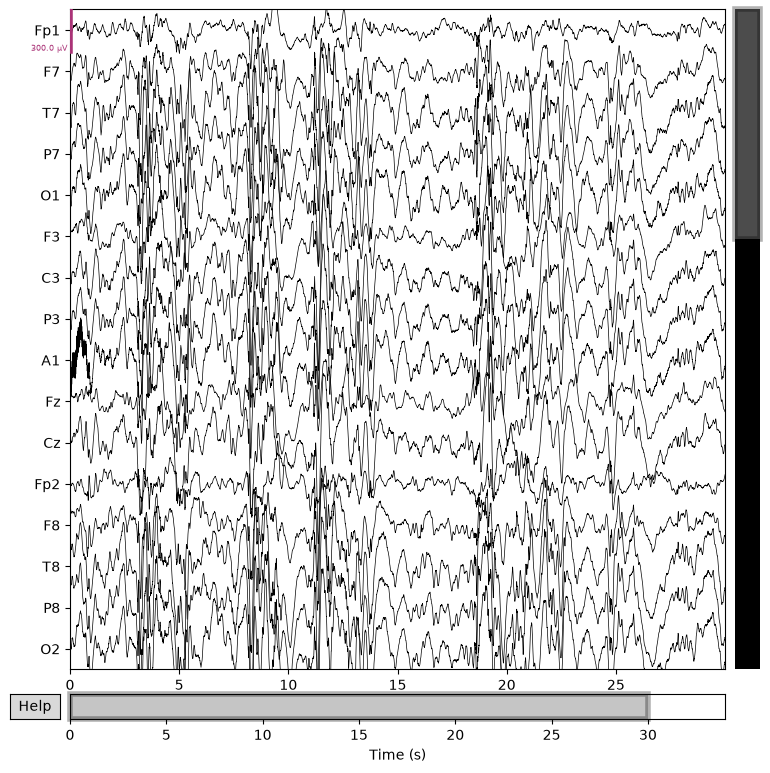

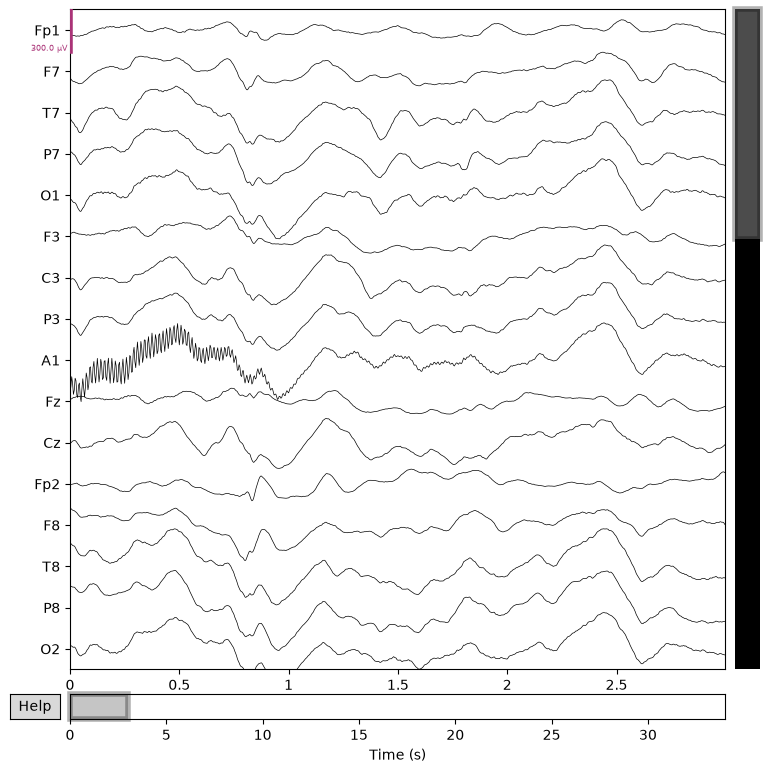

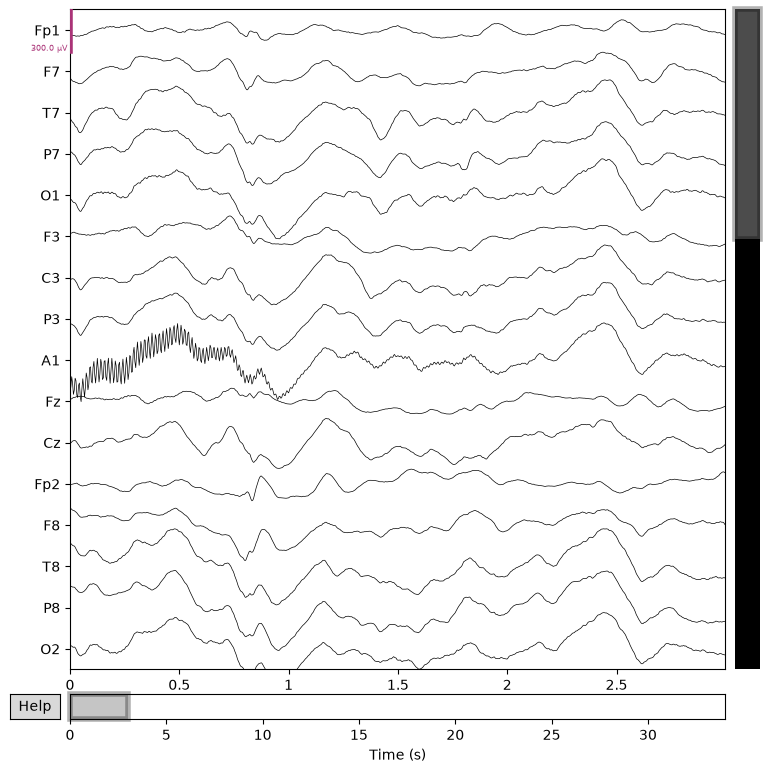

In [44]:
raw = load_single_epoch(r"J:\Research\Barb Research\Nie, Duyu\Multimodal Biomarker Epilepsies Study\Data\EDF files\Fully De-Identified\ELE03_N2_Pre.edf")
raw.plot(duration=30, n_channels=16, scalings=dict(eeg=150e-6))
raw.plot(duration=3, n_channels=16, scalings=dict(eeg=150e-6))

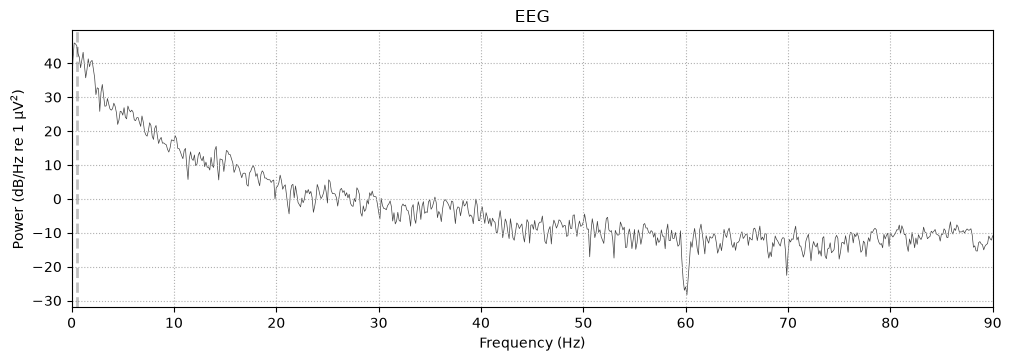

In [45]:
raw_c3 = raw.copy().pick(["C3"])
raw_c3.compute_psd(fmax=90).plot()

In [ ]:
# ----------------------------------------------------------------------
# 3. PSD COMPUTATION (per epoch, per channel)
# ----------------------------------------------------------------------
 
def compute_epoch_psds(epochs):
    """
    Welch PSD per epoch, per channel.
 
    Returns
    -------
    freqs : ndarray, shape (n_freqs,)
    psds  : ndarray, shape (n_epochs, n_channels, n_freqs)
    ch_names : list of channel names
    """
    sfreq = epochs.info["sfreq"]
    n_fft = int(sfreq * 4)          # 4-second Welch window
    n_overlap = int(n_fft * WELCH_N_OVERLAP_FRAC)
 
    spectrum = epochs.compute_psd(
        method="welch",
        fmin=0.5, fmax=45.0,
        n_fft=n_fft, n_overlap=n_overlap,
        average="mean",
    )
    psds, freqs = spectrum.get_data(return_freqs=True)  # (n_epochs, n_ch, n_freqs)
    return freqs, psds, epochs.ch_names
 

In [ ]:
# ----------------------------------------------------------------------
# 4. SPECPARAM (FOOOF) FITTING
# ----------------------------------------------------------------------
 
def fit_aperiodic(freqs, psd_1d):
    """
    Fit one power spectrum (already averaged or single epoch/channel).
 
    Returns dict with aperiodic offset/exponent (+ knee if used) and,
    for convenience, per-band peak power extracted from the *periodic*
    component only (i.e. oscillatory power with the 1/f background removed).
    """
    model = SpectralModel(
        aperiodic_mode=APERIODIC_MODE,
        peak_width_limits=(1.0, 8.0),
        max_n_peaks=8,
        min_peak_height=0.05,
        peak_threshold=2.0,
        verbose=False,
    )
    model.fit(freqs, psd_1d, freq_range=FIT_FREQ_RANGE)
 
    out = {}
    ap_params = model.get_params("aperiodic")
    if APERIODIC_MODE == "knee":
        out["offset"], out["knee"], out["exponent"] = ap_params
    else:
        out["offset"], out["exponent"] = ap_params
        out["knee"] = np.nan
 
    metrics = model.results.metrics.results
    out["r_squared"] = metrics.get("gof_rsquared", np.nan)
    out["error"] = metrics.get("error_mae", np.nan)
 
    # Periodic (peak) power per band, aperiodic-corrected
    peak_params = model.get_params("peak")
    for band_name, band_range in BANDS:
        band_peak = get_band_peak_arr(peak_params, band_range, select_highest=True)
        # band_peak is [CF, PW, BW], filled with nan if no peak found in range
        out[f"periodic_{band_name}_cf"] = band_peak[0]
        out[f"periodic_{band_name}_power"] = band_peak[1]
        out[f"periodic_{band_name}_bw"] = band_peak[2]
 
    return out
 

In [ ]:
# ----------------------------------------------------------------------
# 5. MAIN PIPELINE
# ----------------------------------------------------------------------
 
def run_pipeline(manifest_csv=MANIFEST_CSV, output_csv=OUTPUT_CSV):
    manifest = pd.read_csv(manifest_csv)
    rows = []
 
    for _, row in manifest.iterrows():
        subject, timepoint, filepath = row["subject"], row["timepoint"], row["filepath"]
        print(f"Processing {subject} / {timepoint} ...")
 
        epochs = load_epochs_for_recording(filepath)
        freqs, psds, ch_names = compute_epoch_psds(epochs)  # (n_ep, n_ch, n_freq)
 
        # Average PSD across epochs first (recording-level spectrum), then
        # fit once per channel. This matches how band power is typically
        # summarized in your pipeline (per-channel, then averaged across a
        # region/all channels). If you'd rather fit epoch-by-epoch to get a
        # distribution (recommended if you want within-recording variance),
        # see `fit_aperiodic_epochwise()` below instead.
        mean_psd = psds.mean(axis=0)  # (n_ch, n_freq)
 
        for ch_idx, ch_name in enumerate(ch_names):
            try:
                fit_result = fit_aperiodic(freqs, mean_psd[ch_idx])
            except Exception as e:
                print(f"  fit failed for {ch_name}: {e}")
                continue
            fit_result.update({
                "subject": subject,
                "timepoint": timepoint,
                "channel": ch_name,
            })
            rows.append(fit_result)
 
    results_df = pd.DataFrame(rows)
    results_df.to_csv(output_csv, index=False)
    print(f"\nSaved {len(results_df)} rows to {output_csv}")
    return results_df
 
 
def fit_aperiodic_epochwise(epochs, freqs=None, psds=None):
    """
    Alternative: fit every single epoch (not just the recording mean),
    per channel, so you get a distribution of exponent/offset values per
    subject/timepoint suitable for a linear mixed-effects model with
    epoch as the repeated-measures unit (mirrors your SWI/spectral LME
    approach). Returns a long-format DataFrame.
    """
    if freqs is None or psds is None:
        freqs, psds, ch_names = compute_epoch_psds(epochs)
    else:
        ch_names = epochs.ch_names
 
    rows = []
    n_epochs, n_ch, _ = psds.shape
    for ep_idx in range(n_epochs):
        for ch_idx, ch_name in enumerate(ch_names):
            try:
                fit_result = fit_aperiodic(freqs, psds[ep_idx, ch_idx])
            except Exception:
                continue
            fit_result.update({"epoch": ep_idx, "channel": ch_name})
            rows.append(fit_result)
    return pd.DataFrame(rows)
 

In [ ]:
# ----------------------------------------------------------------------
# 6. STATISTICS -- Linear Mixed-Effects across Pre/Post1/Post2
# ----------------------------------------------------------------------
 
def run_lme(results_df, dependent_var="exponent"):
    """
    Mirrors the LME approach in your spectral analysis: timepoint as a
    fixed effect, subject (and optionally channel) as random effects.
    Requires >1 observation per subject/timepoint (e.g. per-channel or
    per-epoch rows) for the random effect to be estimable.
    """
    import statsmodels.formula.api as smf
 
    df = results_df.copy()
    df["timepoint"] = pd.Categorical(df["timepoint"], categories=["Pre", "Post1", "Post2"], ordered=True)
 
    model = smf.mixedlm(
        f"{dependent_var} ~ C(timepoint, Treatment(reference='Pre'))",
        data=df,
        groups=df["subject"],
    )
    result = model.fit()
    print(result.summary())
    return result
 
 
if __name__ == "__main__":
    df = run_pipeline()
    print("\n--- Aperiodic exponent across timepoints (mean +/- SD) ---")
    print(df.groupby("timepoint")["exponent"].agg(["mean", "std", "count"]))
 
    print("\n--- LME: exponent ~ timepoint ---")
    run_lme(df, dependent_var="exponent")
 
    print("\n--- LME: offset ~ timepoint ---")
    run_lme(df, dependent_var="offset")
 